In [1]:
import pandas as pd
import numpy as np
from loader import load_features, preprocess_features
from specral_privacy_pipeline import DPLaplacianEigenmaps, PPSPLaplacianNoise, SpectralGapNoise, EmbeddingPerturbation
from ml_pipeline import run_classification, run_cv_inference_attack, display_classification_results

# Loading Feature Set & Preprocessing

In [2]:
x, y, target_names = load_features(
    file_path="features_raw_0_overlap.csv",
    meta_cols=['file_id', 'fault_size', 'load'],
    label_col='label'
)
X_scaled = preprocess_features(x)

In [3]:
all_classes = list(range(len(target_names)))
print("All classes:", all_classes)

All classes: [0, 1, 2, 3]


In [4]:
def safe_loc(df, row, col, default=np.nan):
    """Return df.loc[row, col] as float, or default if row/col is missing."""
    if row in df.index and col in df.columns:
        return float(df.loc[row, col])
    return default

In [5]:
def run_attack_all_classes(X, y, target_names, verbose=False):
    """Run inference attack for every class and average the metrics across classes."""
    per_class_results = []
    for cls_idx, cls_name in enumerate(target_names):
        atk_df = run_cv_inference_attack(
            X, y,
            sensitive_class=cls_idx,
            verbose=verbose,
        )
        per_class_results.append(atk_df)
        if verbose:
            print(f"--- Attack results for class '{cls_name}' ---")
            print(atk_df)

    if not per_class_results:
        raise ValueError("No per-class results were produced.")

    # Identify numeric columns (intersection across all DFs, in case columns differ)
    numeric_cols = per_class_results[0].select_dtypes(include=[np.number]).columns
    for df in per_class_results[1:]:
        numeric_cols = numeric_cols.intersection(
            df.select_dtypes(include=[np.number]).columns
        )
    numeric_cols = numeric_cols.tolist()

    if not numeric_cols:
        raise ValueError(
            "No common numeric columns across per-class attack results. "
            f"First df columns: {per_class_results[0].columns.tolist()}"
        )

    # Union of all row indices — keep every row that appears at least once
    all_idx = per_class_results[0].index
    for df in per_class_results[1:]:
        all_idx = all_idx.union(df.index)

    # Reindex each DataFrame to the union, fill missing rows with NaN,
    # restrict to numeric columns
    aligned = [
        df.reindex(all_idx)[numeric_cols].astype(float)
        for df in per_class_results
    ]
    stacked = np.stack([df.to_numpy() for df in aligned])
    # shape: (n_classes, n_rows, n_numeric_cols)

    # NaN-aware mean across classes
    avg_array = np.nanmean(stacked, axis=0)
    avg_df = pd.DataFrame(avg_array, index=all_idx, columns=numeric_cols)

    # Diagnostics: count how many classes contributed to each ROW
    # A row is "present" for a class if any of its numeric cells is non-NaN
    presence_per_row = np.any(~np.isnan(stacked), axis=2)  # (n_classes, n_rows)
    presence_count = presence_per_row.sum(axis=0)          # (n_rows,)

    n_classes = len(per_class_results)
    partial_rows = [
        (idx, int(cnt)) for idx, cnt in zip(all_idx, presence_count) if cnt < n_classes
    ]
    if partial_rows and verbose:
        print(f"\n[note] Rows missing from some classes (averaged over present ones):")
        for idx, cnt in partial_rows:
            print(f"  '{idx}': present in {cnt}/{n_classes} classes")

    return avg_df, per_class_results

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from neigbourhood_viz import (
    visualize_graph_perturbation,
    visualize_embedding_shift,
    _reduce_2d,
)


def safe_loc(df, row, col, default=np.nan):
    """Return df.loc[row, col] as float, or default if missing."""
    if row in df.index and col in df.columns:
        return float(df.loc[row, col])
    return default


def fmt(x, spec=".4f"):
    """Format a number, or return 'N/A' if it's None/NaN."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/A"
    return format(x, spec)


# ── Output directory for figures ─────────────────────────────────────────
FIG_DIR = "figures/neighbourhood_viz"
os.makedirs(FIG_DIR, exist_ok=True)

epsilons = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

records = {"Noisy Embedding": []}
fiedler_records = []
baseline_records = []

# ── Precompute a shared 2D layout so all epsilon panels are comparable ───
shared_coords, layout_method = _reduce_2d(
    StandardScaler().fit_transform(X_scaled), method="umap"
)
print(f"Computed shared {layout_method} layout for visualizations.")

for eps in epsilons:
    model = DPLaplacianEigenmaps(
        n_neighbors=27,
        n_components=4,
        noise_mechanism=SpectralGapNoise(epsilon=eps),
    )
    results = model.fit_transform(X_scaled)

    # ── Baseline stages (run only once, on the first epsilon) ───────────
    if eps == epsilons[0]:
        for title, X in {
            "Raw Features": X_scaled,
            "Clean Embedding": results["embedding_clean"],
        }.items():
            print(f"=== Stage: {title} ===")
            clf_res_base = run_classification(X, y, target_names)
            display_classification_results(clf_res_base)
            avg_df_base, _ = run_attack_all_classes(X, y, target_names)
            print("Averaged attack metrics across all classes:")
            print(avg_df_base)

            baseline_records.append({
                "stage": title,
                "macro_f1": clf_res_base["Random Forest"]["macro_f1"],
                "adv_auc": safe_loc(avg_df_base, "Logistic Regression (LR)", "Adv AUC"),
                "adv_acc": safe_loc(avg_df_base, "Logistic Regression (LR)", "Adv Accuracy"),
                "priv_gain": safe_loc(avg_df_base, "Logistic Regression (LR)", "Privacy Gain"),
                "random_baseline_priv_gain": safe_loc(
                    avg_df_base, "Random Baseline", "Privacy Gain"
                ),
            })

    # ── Fiedler gap tracking ────────────────────────────────────────────
    fiedler_clean = results.get("fiedler_gap_clean")
    fiedler_noisy = results.get("fiedler_gap_noisy")
    fiedler_ratio = (
        fiedler_noisy / fiedler_clean
        if fiedler_clean and fiedler_clean > 0 and fiedler_noisy is not None
        else np.nan
    )
    fiedler_delta = (
        fiedler_noisy - fiedler_clean
        if fiedler_clean is not None and fiedler_noisy is not None
        else np.nan
    )
    fiedler_records.append({
        "epsilon": eps,
        "fiedler_clean": fiedler_clean,
        "fiedler_noisy": fiedler_noisy,
        "fiedler_ratio": fiedler_ratio,
        "fiedler_delta": fiedler_delta,
    })

    # ── Noisy embedding stage: classification + attack ──────────────────
    stages = {"Noisy Embedding": results["embedding_noisy"]}

    for title, X in stages.items():
        print(
            f"=== Stage: {title} - ε={eps} === "
            f"Noise Scale: {results['noise_metadata']['scale']:.4f} === "
            f"Spectral Gap: {results['noise_metadata']['gap']:.4f} === "
            f"Noise-to-Gap Ratio: {results['noise_metadata']['noise_to_gap']:.4f} === "
            f"Fiedler (clean→noisy): {fmt(fiedler_clean)} → {fmt(fiedler_noisy)} ==="
        )

        clf_res = run_classification(X, y, target_names)
        display_classification_results(clf_res)

        avg_atk_df, per_class_dfs = run_attack_all_classes(
            X, y, target_names, verbose=True
        )
        print("Averaged attack metrics across all classes:")
        print(avg_atk_df)

        records[title].append({
            "epsilon": eps,
            "macro_f1": clf_res["Random Forest"]["macro_f1"],
            "adv_auc": safe_loc(avg_atk_df, "Logistic Regression (LR)", "Adv AUC"),
            "adv_acc": safe_loc(avg_atk_df, "Logistic Regression (LR)", "Adv Accuracy"),
            "priv_gain": safe_loc(avg_atk_df, "Logistic Regression (LR)", "Privacy Gain"),
            "random_baseline_priv_gain": safe_loc(
                avg_atk_df, "Random Baseline", "Privacy Gain"
            ),
            "noise_scale": results["noise_metadata"]["scale"],
            "spectral_gap": results["noise_metadata"]["gap"],
            "noise_to_gap": results["noise_metadata"]["noise_to_gap"],
            "fiedler_clean": fiedler_clean,
            "fiedler_noisy": fiedler_noisy,
            "fiedler_ratio": fiedler_ratio,
        })

    # ── Neighbourhood visualization (saved per epsilon) ─────────────────
    fig_graph, _ = visualize_graph_perturbation(
        X_scaled, y, results,
        target_names=target_names,
        coords=shared_coords,
    )
    fig_graph.suptitle(f"k-NN graph perturbation at ε={eps}", y=1.02, fontsize=13)
    graph_path = os.path.join(FIG_DIR, f"graph_perturbation_eps_{eps}.png")
    fig_graph.savefig(graph_path, dpi=150, bbox_inches="tight")
    plt.close(fig_graph)
    print(f"Saved graph perturbation figure → {graph_path}")

    fig_emb = visualize_embedding_shift(
        results, y, target_names=target_names, method="umap",
    )
    fig_emb.suptitle(f"Embedding shift at ε={eps}", y=1.02, fontsize=13)
    emb_path = os.path.join(FIG_DIR, f"embedding_shift_eps_{eps}.png")
    fig_emb.savefig(emb_path, dpi=150, bbox_inches="tight")
    plt.close(fig_emb)
    print(f"Saved embedding shift figure → {emb_path}")


# ── Convert records to DataFrames for easy plotting later ───────────────
df_metrics = pd.DataFrame(records["Noisy Embedding"])
df_fiedler = pd.DataFrame(fiedler_records)
df_baseline = pd.DataFrame(baseline_records)

print("\n=== Metrics across epsilon sweep ===")
print(df_metrics)
print("\n=== Fiedler gap evolution ===")
print(df_fiedler)
print("\n=== Baseline (unperturbed) reference ===")
print(df_baseline)

df_metrics.to_csv("records_metrics.csv", index=False)
df_fiedler.to_csv("records_fiedler.csv", index=False)
df_baseline.to_csv("records_baseline.csv", index=False)

Computed shared t-SNE layout for visualizations.
=== Stage: Raw Features ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.994,0.996,0.994,0.995
2,SVM,0.981,0.982,0.981,0.982
4,Decision Tree,0.973,0.974,0.975,0.974
3,KNN,0.962,0.962,0.967,0.964
0,Logistic Regression,0.954,0.963,0.952,0.957


Averaged attack metrics across all classes:
                          Adv Accuracy  Random Baseline  Privacy Gain  \
Logistic Regression (LR)      0.990325         0.750025     -0.240325   

                          Norm Gain   Adv F1  Adv AUC  
Logistic Regression (LR)    0.96395  0.98225  0.99865  
=== Stage: Clean Embedding ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.924,0.927,0.926,0.927
1,Random Forest,0.920,0.926,0.922,0.924
4,Decision Tree,0.898,0.905,0.902,0.903
2,SVM,0.730,0.820,0.728,0.711
0,Logistic Regression,0.572,0.867,0.497,0.465


Averaged attack metrics across all classes:
                          Adv Accuracy  Random Baseline  Privacy Gain  \
Logistic Regression (LR)      0.785325         0.750025      -0.03535   

                          Norm Gain    Adv F1   Adv AUC  
Logistic Regression (LR)     0.1914  0.586425  0.815675  
=== Stage: Noisy Embedding - ε=0.05 === Noise Scale: 0.3418 === Spectral Gap: 0.0005 === Noise-to-Gap Ratio: 697.2631 === Fiedler (clean→noisy): 0.0000 → 0.0004 ===


...


  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.5501 +0.2338 -1.0824 0.6785  ✓ private

--- Attack results for class 'B' ---
                          Adv Accuracy  Random Baseline  Privacy Gain  \
Logistic Regression (LR)        0.5501            0.784        0.2338   

                          Norm Gain  Adv F1  Adv AUC  
Logistic Regression (LR)    -1.0824  0.4633   0.6785  

  Inference Attack
  Sensitive class : 1
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7841

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.8480 -0.0639 0.2958 0.7681  ✗ leaked

--- Attack results for class 'IR' ---
            

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.911,0.915,0.912,0.913
1,Random Forest,0.903,0.909,0.904,0.906
4,Decision Tree,0.878,0.882,0.882,0.882
2,SVM,0.732,0.764,0.740,0.724
0,Logistic Regression,0.425,0.599,0.303,0.231



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7259 +0.0581 -0.2687 0.4742  ✓ private

--- Attack results for class 'B' ---
                          Adv Accuracy  Random Baseline  Privacy Gain  \
Logistic Regression (LR)        0.7259            0.784        0.0581   

                          Norm Gain  Adv F1  Adv AUC  
Logistic Regression (LR)    -0.2687  0.2816   0.4742  

  Inference Attack
  Sensitive class : 1
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7841

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.8223 -0.0382 0.1770 0.8330  ✗ leaked

--- Attack results for class 'IR' ---
            

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.921,0.926,0.923,0.924
1,Random Forest,0.917,0.923,0.920,0.921
4,Decision Tree,0.900,0.906,0.904,0.905
2,SVM,0.726,0.764,0.732,0.713
0,Logistic Regression,0.426,0.599,0.304,0.232



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7266 +0.0574 -0.2656 0.5777  ✓ private

--- Attack results for class 'B' ---
                          Adv Accuracy  Random Baseline  Privacy Gain  \
Logistic Regression (LR)        0.7266            0.784        0.0574   

                          Norm Gain  Adv F1  Adv AUC  
Logistic Regression (LR)    -0.2656  0.2821   0.5777  

  Inference Attack
  Sensitive class : 1
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7841

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.8234 -0.0394 0.1823 0.8452  ✗ leaked

--- Attack results for class 'IR' ---
            

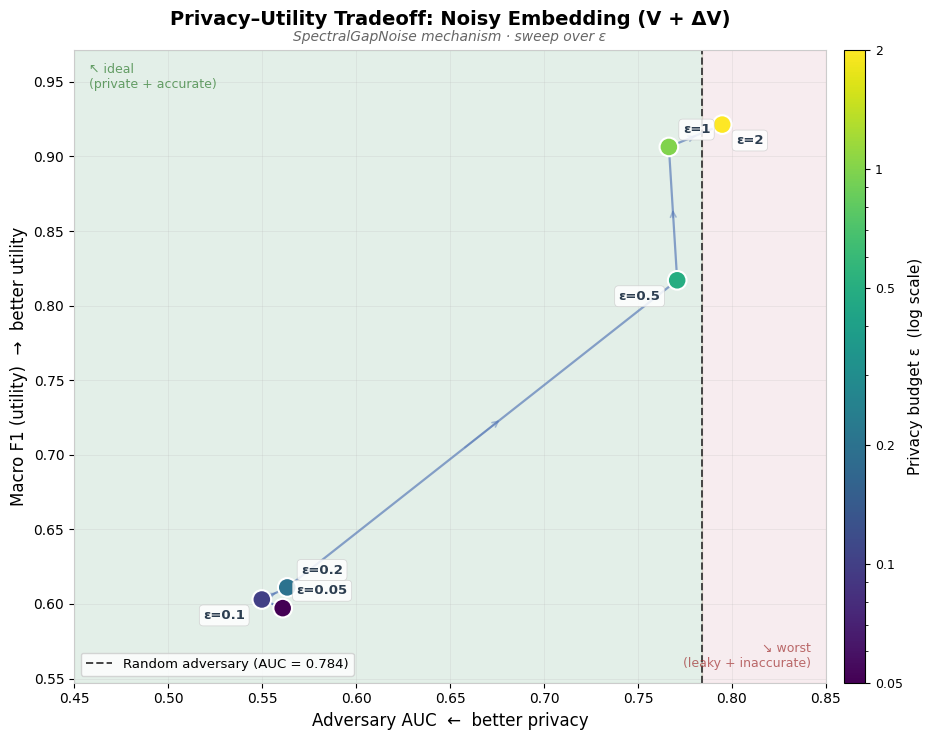

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

stage_titles = {
    "Noisy Embedding": "Noisy Embedding (V + ΔV)",
}

# ── Color setup: log-normalize ε so spacing reflects perceptual scale ───
eps_arr = np.array(epsilons, dtype=float)
norm = mcolors.LogNorm(vmin=eps_arr.min(), vmax=eps_arr.max())
cmap = cm.viridis

# Random-guessing baseline for adversary AUC
RANDOM_AUC = 0.784

for stage, recs in records.items():
    # Sort by ε so the connecting line traces the sweep monotonically
    recs_sorted = sorted(recs, key=lambda r: r["epsilon"])
    adv_aucs = np.array([r["adv_auc"] for r in recs_sorted])
    f1s = np.array([r["macro_f1"] for r in recs_sorted])
    eps_vals = np.array([r["epsilon"] for r in recs_sorted])

    fig, ax = plt.subplots(figsize=(10, 7.5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#F7F9FC")

    # ── Quadrant shading: highlight the "sweet spot" ───────────────────
    # Top-left = high utility + low adversary AUC = ideal
    xlim_lo, xlim_hi = 0.45, max(adv_aucs.max() + 0.05, 0.85)
    ylim_lo, ylim_hi = max(f1s.min() - 0.05, 0), min(f1s.max() + 0.05, 1.0)

    ax.axvspan(xlim_lo, RANDOM_AUC, alpha=0.08, color="green", zorder=0)
    ax.axvspan(RANDOM_AUC, xlim_hi, alpha=0.05, color="red", zorder=0)

    # ── Trajectory line connecting epsilons in order ───────────────────
    ax.plot(
        adv_aucs, f1s,
        color="#5B7CB8", linewidth=1.6, alpha=0.7,
        zorder=2, linestyle="-",
    )

    # Direction arrows along the trajectory (subtle)
    for i in range(len(adv_aucs) - 1):
        dx = adv_aucs[i + 1] - adv_aucs[i]
        dy = f1s[i + 1] - f1s[i]
        ax.annotate(
            "", xy=(adv_aucs[i] + dx * 0.55, f1s[i] + dy * 0.55),
            xytext=(adv_aucs[i] + dx * 0.45, f1s[i] + dy * 0.45),
            arrowprops=dict(arrowstyle="->", color="#5B7CB8", alpha=0.5, lw=1.2),
            zorder=2,
        )

    # ── Points colored by ε ────────────────────────────────────────────
    sc = ax.scatter(
        adv_aucs, f1s,
        c=eps_vals, cmap=cmap, norm=norm,
        s=180, zorder=3,
        edgecolors="white", linewidths=1.5,
    )

    # ── Smart label placement: alternate offset direction ──────────────
    for i, (auc, f1, eps) in enumerate(zip(adv_aucs, f1s, eps_vals)):
        # Push label away from trajectory direction
        if i == 0:
            offset = (10, 10)
            ha = "left"
        elif i == len(adv_aucs) - 1:
            offset = (10, -14)
            ha = "left"
        else:
            offset = (10, 10) if i % 2 == 0 else (-12, -14)
            ha = "left" if i % 2 == 0 else "right"

        ax.annotate(
            f"ε={eps:g}",
            xy=(auc, f1),
            xytext=offset, textcoords="offset points",
            fontsize=9.5, color="#2C3E50", fontweight="bold",
            ha=ha,
            bbox=dict(
                boxstyle="round,pad=0.3", facecolor="white",
                edgecolor="#CCCCCC", alpha=0.85, linewidth=0.5,
            ),
        )

    # ── Reference lines ────────────────────────────────────────────────
    ax.axvline(
        RANDOM_AUC, color="#444444", linestyle="--", linewidth=1.4,
        label=f"Random adversary (AUC = {RANDOM_AUC})", zorder=1,
    )

    # ── Axis cosmetics ─────────────────────────────────────────────────
    ax.set_xlim(xlim_lo, xlim_hi)
    ax.set_ylim(ylim_lo, ylim_hi)

    ax.set_xlabel(
        "Adversary AUC  ←  better privacy",
        fontsize=12, fontweight="medium",
    )
    ax.set_ylabel(
        "Macro F1 (utility)  →  better utility",
        fontsize=12, fontweight="medium",
    )

    ax.set_title(
        f"Privacy–Utility Tradeoff: {stage_titles[stage]}",
        fontsize=14, fontweight="bold", pad=18,
    )
    ax.text(
        0.5, 1.015, "SpectralGapNoise mechanism · sweep over ε",
        transform=ax.transAxes, ha="center", fontsize=10,
        color="#666666", style="italic",
    )

    # ── Quadrant annotations ───────────────────────────────────────────
    ax.text(
        0.02, 0.98, "↖ ideal\n(private + accurate)",
        transform=ax.transAxes, fontsize=9, color="#2D7A2D",
        va="top", ha="left", alpha=0.7, fontweight="medium",
    )
    ax.text(
        0.98, 0.02, "↘ worst\n(leaky + inaccurate)",
        transform=ax.transAxes, fontsize=9, color="#A03030",
        va="bottom", ha="right", alpha=0.7, fontweight="medium",
    )

    # ── Colorbar ───────────────────────────────────────────────────────
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, aspect=30)
    cbar.set_label("Privacy budget ε  (log scale)", fontsize=11)
    cbar.ax.tick_params(labelsize=9)
    # Show actual ε values as ticks
    cbar.set_ticks(eps_arr)
    cbar.set_ticklabels([f"{e:g}" for e in eps_arr])

    # ── Grid & spines ──────────────────────────────────────────────────
    ax.grid(True, alpha=0.25, linestyle="-", linewidth=0.5)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color("#CCCCCC")
        spine.set_linewidth(0.8)

    ax.legend(
        loc="lower left", fontsize=9.5,
        frameon=True, facecolor="white", edgecolor="#CCCCCC",
    )

    plt.tight_layout()
    plt.show()

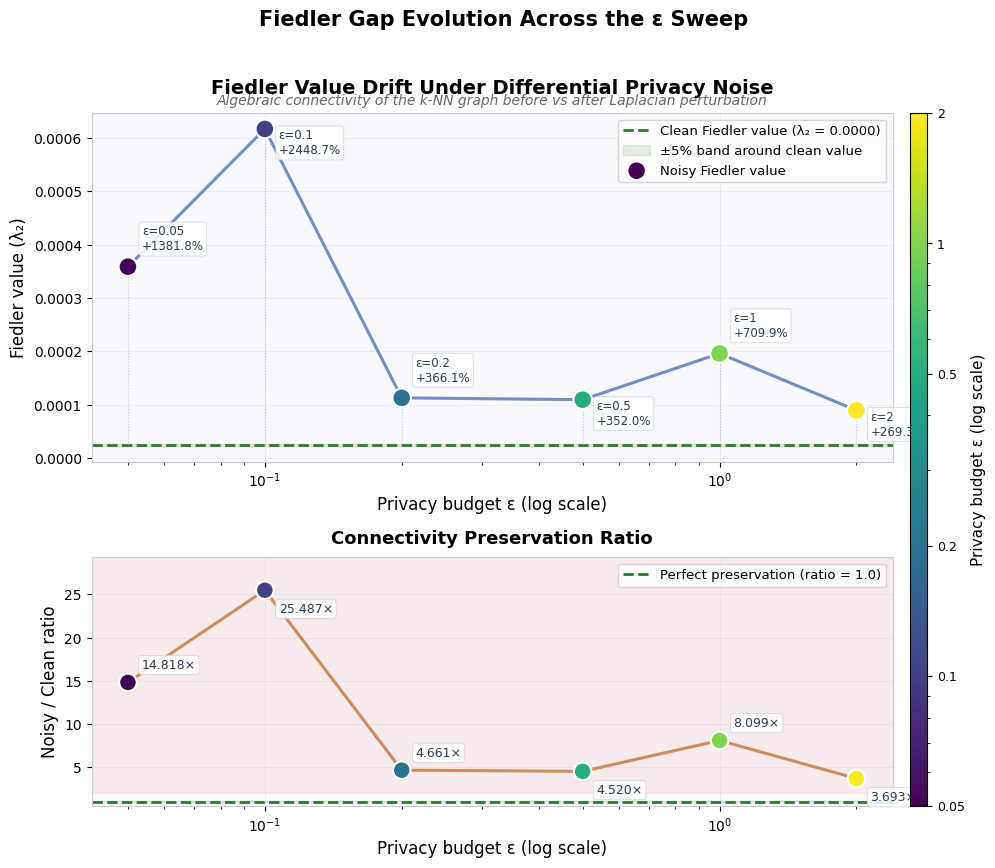

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# ── Extract data ──────────────────────────────────────────────────────────
eps_vals      = np.array([r["epsilon"]       for r in fiedler_records])
fiedler_clean = np.array([r["fiedler_clean"] for r in fiedler_records])
fiedler_noisy = np.array([r["fiedler_noisy"] for r in fiedler_records])
fiedler_ratio = np.array([r["fiedler_ratio"] for r in fiedler_records])

# Sort by epsilon (defensive — should already be sorted)
order = np.argsort(eps_vals)
eps_vals      = eps_vals[order]
fiedler_clean = fiedler_clean[order]
fiedler_noisy = fiedler_noisy[order]
fiedler_ratio = fiedler_ratio[order]

clean_value = fiedler_clean[0]   # constant across the sweep

# ── Figure: two stacked panels ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 9),
    gridspec_kw={"height_ratios": [1.4, 1], "hspace": 0.32},
)
fig.patch.set_facecolor("white")

cmap = cm.viridis
norm = mcolors.LogNorm(vmin=eps_vals.min(), vmax=eps_vals.max())

# ═══════════════ PANEL 1: Absolute Fiedler values ══════════════════════════
ax1.set_facecolor("#F7F9FC")

# Clean reference: horizontal band
ax1.axhline(
    clean_value, color="#2D7A2D", linestyle="--", linewidth=2,
    label=f"Clean Fiedler value (λ₂ = {clean_value:.4f})", zorder=2,
)
ax1.axhspan(
    clean_value * 0.95, clean_value * 1.05,
    alpha=0.12, color="#2D7A2D", zorder=1,
    label="±5% band around clean value",
)

# Noisy trajectory
ax1.plot(
    eps_vals, fiedler_noisy,
    color="#5B7CB8", linewidth=2.2, alpha=0.85,
    zorder=3, marker=None,
)
sc = ax1.scatter(
    eps_vals, fiedler_noisy,
    c=eps_vals, cmap=cmap, norm=norm,
    s=180, zorder=4,
    edgecolors="white", linewidths=1.5,
    label="Noisy Fiedler value",
)

# Drop lines from each noisy point to clean reference (visual delta cue)
for eps, noisy in zip(eps_vals, fiedler_noisy):
    ax1.plot(
        [eps, eps], [clean_value, noisy],
        color="#999999", linewidth=0.8, alpha=0.5,
        linestyle=":", zorder=2,
    )

# Per-point labels
for i, (eps, noisy) in enumerate(zip(eps_vals, fiedler_noisy)):
    delta_pct = 100 * (noisy - clean_value) / clean_value
    sign = "+" if delta_pct >= 0 else ""
    offset = (10, 12) if i % 2 == 0 else (10, -18)
    ax1.annotate(
        f"ε={eps:g}\n{sign}{delta_pct:.1f}%",
        xy=(eps, noisy),
        xytext=offset, textcoords="offset points",
        fontsize=8.5, color="#2C3E50", fontweight="medium",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.25", facecolor="white",
            edgecolor="#CCCCCC", alpha=0.85, linewidth=0.5,
        ),
    )

ax1.set_xscale("log")
ax1.set_xlabel("Privacy budget ε (log scale)", fontsize=12, fontweight="medium")
ax1.set_ylabel("Fiedler value (λ₂)", fontsize=12, fontweight="medium")
ax1.set_title(
    "Fiedler Value Drift Under Differential Privacy Noise",
    fontsize=14, fontweight="bold", pad=14,
)
ax1.text(
    0.5, 1.025, "Algebraic connectivity of the k-NN graph before vs after Laplacian perturbation",
    transform=ax1.transAxes, ha="center", fontsize=10,
    color="#666666", style="italic",
)
ax1.legend(loc="best", fontsize=9.5, frameon=True,
           facecolor="white", edgecolor="#CCCCCC")
ax1.grid(True, alpha=0.25, linewidth=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_color("#CCCCCC")
    spine.set_linewidth(0.8)

# ═══════════════ PANEL 2: Ratio (noisy / clean) ════════════════════════════
ax2.set_facecolor("#F7F9FC")

# Reference line: ratio = 1.0 (perfect preservation)
ax2.axhline(
    1.0, color="#2D7A2D", linestyle="--", linewidth=2,
    label="Perfect preservation (ratio = 1.0)", zorder=2,
)
# Tolerance band
ax2.axhspan(0.95, 1.05, alpha=0.12, color="#2D7A2D", zorder=1)

# Highlight the "structurally broken" region
y_max_panel2 = max(fiedler_ratio.max() * 1.15, 1.5)
y_min_panel2 = min(fiedler_ratio.min() * 0.85, 0.5)
ax2.axhspan(y_max_panel2, 2.0, alpha=0.06, color="red", zorder=0)
ax2.axhspan(0, 0.5, alpha=0.06, color="red", zorder=0)

# Trajectory
ax2.plot(
    eps_vals, fiedler_ratio,
    color="#C77B43", linewidth=2.2, alpha=0.85, zorder=3,
)
ax2.scatter(
    eps_vals, fiedler_ratio,
    c=eps_vals, cmap=cmap, norm=norm,
    s=160, zorder=4,
    edgecolors="white", linewidths=1.5,
)

# Labels showing exact ratio
for i, (eps, ratio) in enumerate(zip(eps_vals, fiedler_ratio)):
    offset = (10, 10) if i % 2 == 0 else (10, -16)
    ax2.annotate(
        f"{ratio:.3f}×",
        xy=(eps, ratio),
        xytext=offset, textcoords="offset points",
        fontsize=9, color="#2C3E50", fontweight="medium",
        bbox=dict(
            boxstyle="round,pad=0.25", facecolor="white",
            edgecolor="#CCCCCC", alpha=0.85, linewidth=0.5,
        ),
    )

ax2.set_xscale("log")
ax2.set_ylim(y_min_panel2, y_max_panel2)
ax2.set_xlabel("Privacy budget ε (log scale)", fontsize=12, fontweight="medium")
ax2.set_ylabel("Noisy / Clean ratio", fontsize=12, fontweight="medium")
ax2.set_title(
    "Connectivity Preservation Ratio",
    fontsize=13, fontweight="bold", pad=10,
)
ax2.legend(loc="best", fontsize=9.5, frameon=True,
           facecolor="white", edgecolor="#CCCCCC")
ax2.grid(True, alpha=0.25, linewidth=0.5)
ax2.set_axisbelow(True)
for spine in ax2.spines.values():
    spine.set_color("#CCCCCC")
    spine.set_linewidth(0.8)

# ── Shared colorbar ───────────────────────────────────────────────────────
cbar = fig.colorbar(sc, ax=[ax1, ax2], pad=0.02, aspect=40, fraction=0.04)
cbar.set_label("Privacy budget ε (log scale)", fontsize=11)
cbar.set_ticks(eps_vals)
cbar.set_ticklabels([f"{e:g}" for e in eps_vals])
cbar.ax.tick_params(labelsize=9)

plt.suptitle(
    "Fiedler Gap Evolution Across the ε Sweep",
    fontsize=15, fontweight="bold", y=0.995,
)

plt.savefig("figures/fiedler_gap_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import connected_components, laplacian
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler


def diagnose_knn_graph(
    X, y=None, target_names=None,
    n_neighbors=10,
    normalized_laplacian=True,
    verbose=True,
):
    """
    Diagnostic checks on the k-NN graph used by Laplacian Eigenmaps.

    Reports:
    - Connectivity (number of components, sizes, class composition)
    - Spectrum (smallest few eigenvalues, Fiedler value, smallest gap)
    - Degree distribution (min/max/avg/zero-degree nodes)
    - Class-graph alignment (within- vs between-class edge ratio)

    Returns a dict of all computed quantities.
    """
    X_scaled = StandardScaler().fit_transform(X)
    n = X_scaled.shape[0]

    # ── Build the graph (matches DPLaplacianEigenmaps) ──────────────────
    A = kneighbors_graph(
        X_scaled, n_neighbors=n_neighbors,
        mode="distance", include_self=False, n_jobs=-1,
    )
    A_sym = 0.5 * (A + A.T)

    report = {"n_nodes": n, "n_neighbors": n_neighbors}

    # ── Connectivity ────────────────────────────────────────────────────
    n_components, comp_labels = connected_components(A_sym, directed=False)
    comp_sizes = np.bincount(comp_labels)
    report["n_components"] = n_components
    report["component_sizes"] = comp_sizes.tolist()

    if verbose:
        print("=" * 72)
        print(f"k-NN GRAPH DIAGNOSTIC (n={n}, k={n_neighbors})")
        print("=" * 72)
        print(f"\n[1] Connectivity")
        print(f"    Connected components: {n_components}")
        if n_components > 1:
            print(f"    Component sizes: {sorted(comp_sizes.tolist(), reverse=True)[:10]}"
                  + (" ..." if n_components > 10 else ""))
            print(f"    Largest component: {comp_sizes.max()}/{n} "
                  f"({100 * comp_sizes.max() / n:.1f}%)")
            singletons = int((comp_sizes == 1).sum())
            print(f"    Singleton nodes: {singletons}")
            print(f"    ⚠ Disconnected graph → λ₂ = 0, gap-aware noise will produce ≈0 noise")
        else:
            print(f"    ✓ Graph is connected")

    # ── Class composition per component (if y given) ────────────────────
    if y is not None and n_components > 1 and verbose:
        print(f"\n    Class composition of largest components:")
        ranked = np.argsort(-comp_sizes)[:5]
        for cid in ranked:
            mask = comp_labels == cid
            if mask.sum() < 2:
                continue
            classes_in_comp, counts = np.unique(y[mask], return_counts=True)
            class_str = ", ".join(
                f"{(target_names[c] if target_names is not None else f'class_{c}')}: {n_}"
                for c, n_ in zip(classes_in_comp, counts)
            )
            print(f"      Component {cid} (size {mask.sum()}): {class_str}")

    # ── Degree distribution ─────────────────────────────────────────────
    degrees = np.asarray(A_sym.astype(bool).sum(axis=1)).ravel()
    report["degree_min"] = int(degrees.min())
    report["degree_max"] = int(degrees.max())
    report["degree_mean"] = float(degrees.mean())
    report["degree_zero_count"] = int((degrees == 0).sum())

    if verbose:
        print(f"\n[2] Node degrees")
        print(f"    Min:  {degrees.min()}")
        print(f"    Max:  {degrees.max()}")
        print(f"    Mean: {degrees.mean():.2f}")
        if (degrees == 0).any():
            print(f"    ⚠ {(degrees == 0).sum()} isolated nodes (degree 0)")

    # ── Spectrum (smallest few eigenvalues) ─────────────────────────────
    L = laplacian(A_sym, normed=normalized_laplacian)
    k_eig = min(6, n - 1)
    try:
        eigvals, _ = eigsh(L, k=k_eig, sigma=0)
        eigvals = np.sort(eigvals)
        report["smallest_eigenvalues"] = eigvals.tolist()
        fiedler = float(eigvals[1]) if len(eigvals) > 1 else float("nan")
        smallest_gap = float(np.min(np.diff(eigvals))) if len(eigvals) > 1 else float("nan")
        report["fiedler_value"] = fiedler
        report["smallest_gap"] = smallest_gap

        if verbose:
            print(f"\n[3] Spectrum (smallest {k_eig} eigenvalues, "
                  f"{'normalized' if normalized_laplacian else 'unnormalized'} L)")
            for i, ev in enumerate(eigvals):
                marker = ""
                if i == 0 and abs(ev) < 1e-8:
                    marker = " (≈ 0, expected)"
                elif i < n_components and abs(ev) < 1e-8:
                    marker = " (≈ 0, indicates extra component)"
                print(f"    λ_{i+1} = {ev:.6e}{marker}")
            print(f"    Fiedler value λ₂: {fiedler:.6e}")
            print(f"    Smallest gap:     {smallest_gap:.6e}")

            if fiedler < 1e-6:
                print(f"    ⚠ Fiedler ≈ 0 → graph is (near-)disconnected")
                print(f"      Gap-aware noise mechanism will add essentially zero noise.")
            elif fiedler < 1e-3:
                print(f"    ⚠ Small Fiedler value → fragile spectrum")
                print(f"      Eigenvectors will be very sensitive to perturbation.")
    except Exception as e:
        if verbose:
            print(f"\n[3] Spectrum: eigendecomposition failed ({type(e).__name__}: {e})")
        report["smallest_eigenvalues"] = None
        report["fiedler_value"] = None
        report["smallest_gap"] = None

    # ── Class-graph alignment ───────────────────────────────────────────
    if y is not None:
        A_coo = sp.triu(A_sym, k=1).tocoo()
        same_class = (y[A_coo.row] == y[A_coo.col])
        within = int(same_class.sum())
        between = int((~same_class).sum())
        total_edges = within + between
        within_frac = within / total_edges if total_edges > 0 else 0.0
        report["edges_within_class"] = within
        report["edges_between_class"] = between
        report["within_class_edge_fraction"] = within_frac

        if verbose:
            print(f"\n[4] Class-graph alignment")
            print(f"    Within-class edges:  {within:,} ({100 * within_frac:.1f}%)")
            print(f"    Between-class edges: {between:,} ({100 * (1 - within_frac):.1f}%)")
            if within_frac > 0.9:
                print(f"    ✓ Strong class structure — graph respects labels")
            elif within_frac > 0.7:
                print(f"    Moderate class structure")
            else:
                print(f"    ⚠ Weak class structure — many edges cross class boundaries")

    # ── Recommendations ─────────────────────────────────────────────────
    if verbose:
        print(f"\n[5] Recommendations")
        if n_components > 1:
            print(f"    • Increase n_neighbors (try {n_neighbors * 2} or {n_neighbors * 3})")
            print(f"      to bridge disconnected components, OR")
            print(f"    • Add cross-component backbone edges, OR")
            print(f"    • Run Laplacian Eigenmaps per-component")
        elif report.get("fiedler_value", 1) < 1e-3:
            print(f"    • Spectrum is fragile; consider increasing n_neighbors")
            print(f"      or using a different graph construction (e.g., Gaussian kernel)")
        else:
            print(f"    ✓ Graph looks healthy for spectral methods")
        print("=" * 72)

    return report


# ── Usage ────────────────────────────────────────────────────────────────
for k in [20, 30, 50, 100]:
    print(f"\n>>> k = {k}")
    report = diagnose_knn_graph(
        X_scaled, y, target_names=target_names,
        n_neighbors=k, verbose=False,
    )
    print(f"  Fiedler λ₂ = {report['fiedler_value']:.4e}")
    print(f"  Smallest gap = {report['smallest_gap']:.4e}")
    print(f"  Within-class edges = {100*report['within_class_edge_fraction']:.1f}%")



>>> k = 20
  Fiedler λ₂ = 3.3008e-05
  Smallest gap = 3.3008e-05
  Within-class edges = 93.3%

>>> k = 30
  Fiedler λ₂ = 2.1681e-05
  Smallest gap = 2.1681e-05
  Within-class edges = 92.1%

>>> k = 50
  Fiedler λ₂ = 1.2593e-05
  Smallest gap = 1.2593e-05
  Within-class edges = 90.0%

>>> k = 100
  Fiedler λ₂ = 3.7548e-05
  Smallest gap = 3.7548e-05
  Within-class edges = 86.0%


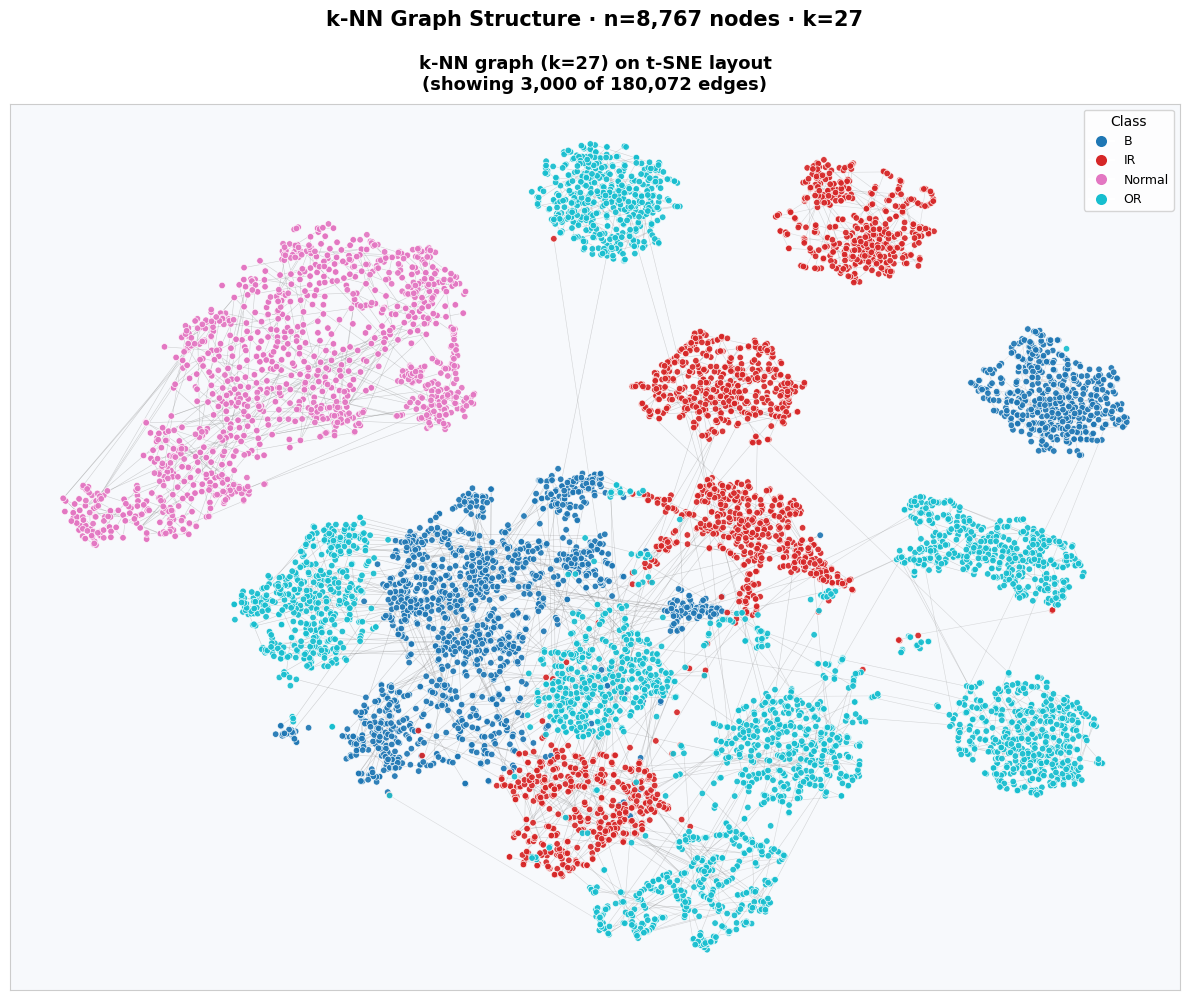

Edges: 180,072
Average degree: 41.08
Median edge distance: 2.7597


In [17]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler


def visualize_knn_graph(
    X, y, target_names=None,
    n_neighbors=27,
    method="umap",
    coords=None,
    figsize=(12, 10),
    max_edges_drawn=3000,
    save_path=None,
):
    """
    Spatial visualization of a k-NN graph: nodes laid out in 2D (UMAP/t-SNE),
    edges drawn between connected nodes, points colored by class.

    Parameters
    ----------
    X : (n, d) array — feature matrix (will be standardized internally)
    y : (n,) array — labels for coloring
    n_neighbors : int — k for k-NN
    method : 'umap' or 'tsne' — for the spatial layout
    coords : optional precomputed 2D layout to reuse
    """
    X_scaled = StandardScaler().fit_transform(X)

    # ── Build the k-NN graph ─────────────────────────────────────────────
    A = kneighbors_graph(
        X_scaled, n_neighbors=n_neighbors,
        mode="distance", include_self=False, n_jobs=-1,
    )
    A_sym = 0.5 * (A + A.T)

    # ── 2D layout ────────────────────────────────────────────────────────
    if coords is None:
        try:
            import umap
            reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
            coords = reducer.fit_transform(X_scaled)
            layout_name = "UMAP"
        except ImportError:
            from sklearn.manifold import TSNE
            coords = TSNE(n_components=2, random_state=42,
                          perplexity=30, init="pca").fit_transform(X_scaled)
            layout_name = "t-SNE"
    else:
        layout_name = method.upper()

    # ── Figure ───────────────────────────────────────────────────────────
    fig, ax_graph = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax_graph.set_facecolor("#F7F9FC")

    # ── Edges ────────────────────────────────────────────────────────────
    A_coo = sp.triu(A_sym, k=1).tocoo()
    n_edges = A_coo.nnz

    if n_edges > max_edges_drawn:
        idx = np.random.default_rng(0).choice(n_edges, max_edges_drawn, replace=False)
        rows, cols, vals = A_coo.row[idx], A_coo.col[idx], A_coo.data[idx]
        edge_note = f"(showing {max_edges_drawn:,} of {n_edges:,} edges)"
    else:
        rows, cols, vals = A_coo.row, A_coo.col, A_coo.data
        edge_note = f"({n_edges:,} edges)"

    # Edge alpha scales inversely with distance — closer pairs darker
    if len(vals) > 0:
        v_max = vals.max()
        for i, j, w in zip(rows, cols, vals):
            alpha = 0.35 * (1 - w / v_max) + 0.05
            ax_graph.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color="#888888", alpha=alpha, linewidth=0.4, zorder=1,
            )

    # ── Nodes ────────────────────────────────────────────────────────────
    ax_graph.scatter(
        coords[:, 0], coords[:, 1],
        c=y, cmap="tab10",
        s=22, alpha=0.92, zorder=3,
        edgecolors="white", linewidths=0.5,
    )

    # ── Cosmetics ────────────────────────────────────────────────────────
    ax_graph.set_title(
        f"k-NN graph (k={n_neighbors}) on {layout_name} layout\n{edge_note}",
        fontsize=13, fontweight="bold", pad=10,
    )
    ax_graph.set_xticks([])
    ax_graph.set_yticks([])
    for spine in ax_graph.spines.values():
        spine.set_color("#CCCCCC")

    if target_names is not None:
        handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=plt.cm.tab10(i / max(len(target_names) - 1, 1)),
                       markersize=9, label=name)
            for i, name in enumerate(target_names)
        ]
        ax_graph.legend(
            handles=handles, loc="upper right", fontsize=9,
            frameon=True, facecolor="white", edgecolor="#CCCCCC",
            title="Class",
        )

    plt.suptitle(
        f"k-NN Graph Structure · n={X.shape[0]:,} nodes · k={n_neighbors}",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    weights = A_sym.data[A_sym.data > 0]
    return {
        "adjacency": A_sym,
        "coords": coords,
        "n_edges": A_sym.nnz // 2,
        "avg_degree": A_sym.nnz / A_sym.shape[0],
        "median_weight": float(np.median(weights)) if len(weights) > 0 else float("nan"),
    }


# ── Usage ────────────────────────────────────────────────────────────────
info = visualize_knn_graph(
    X_scaled, y, target_names=target_names,
    n_neighbors=27,
    save_path="figures/knn_graph_structure.png",
)
print(f"Edges: {info['n_edges']:,}")
print(f"Average degree: {info['avg_degree']:.2f}")
print(f"Median edge distance: {info['median_weight']:.4f}")